In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Size of the dataset
df = pd.read_csv("athlete_events.csv")
print(df.shape)

(271116, 15)


In [2]:
print(df.columns)
print(df.shape)

Index(['ID', 'Name', 'Sex', 'Age', 'Height', 'Weight', 'Team', 'NOC', 'Games',
       'Year', 'Season', 'City', 'Sport', 'Event', 'Medal'],
      dtype='str')
(271116, 15)


In [3]:
print(df.head())
print(df.columns)
print(df.shape)

   ID                      Name Sex   Age  Height  Weight            Team  \
0   1                 A Dijiang   M  24.0   180.0    80.0           China   
1   2                  A Lamusi   M  23.0   170.0    60.0           China   
2   3       Gunnar Nielsen Aaby   M  24.0     NaN     NaN         Denmark   
3   4      Edgar Lindenau Aabye   M  34.0     NaN     NaN  Denmark/Sweden   
4   5  Christine Jacoba Aaftink   F  21.0   185.0    82.0     Netherlands   

   NOC        Games  Year  Season       City          Sport  \
0  CHN  1992 Summer  1992  Summer  Barcelona     Basketball   
1  CHN  2012 Summer  2012  Summer     London           Judo   
2  DEN  1920 Summer  1920  Summer  Antwerpen       Football   
3  DEN  1900 Summer  1900  Summer      Paris     Tug-Of-War   
4  NED  1988 Winter  1988  Winter    Calgary  Speed Skating   

                              Event Medal  
0       Basketball Men's Basketball   NaN  
1      Judo Men's Extra-Lightweight   NaN  
2           Football Men's

In [4]:
df = df.drop_duplicates(
    subset=['ID', 'Name', 'Sex', 'Age', 'Height', 'Weight', 'Team', 'NOC', 'Games',
       'Year', 'Season', 'City', 'Sport', 'Event', 'Medal']
)

print(df.columns)
print(df.shape)

Index(['ID', 'Name', 'Sex', 'Age', 'Height', 'Weight', 'Team', 'NOC', 'Games',
       'Year', 'Season', 'City', 'Sport', 'Event', 'Medal'],
      dtype='str')
(269731, 15)


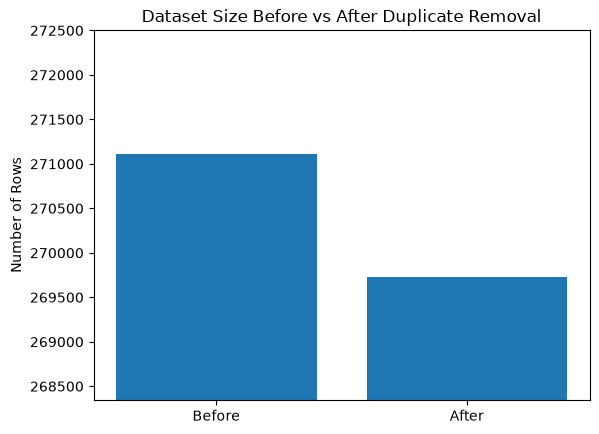

Duplicates removed: 1385
Percentage removed: 0.51%


In [5]:
before = 271116
after = len(df)

plt.bar(
    ["Before", "After"],
    [before, after]
)

minimum = min(before, after)
maximum = max(before, after)

plt.ylim(
    minimum - (maximum - minimum),
    maximum + (maximum - minimum)
)

plt.ylabel("Number of Rows")
plt.title("Dataset Size Before vs After Duplicate Removal")

plt.show()
removed = before - after
percentage_removed = (removed / before) * 100

print("Duplicates removed:", removed)
print(f"Percentage removed: {percentage_removed:.2f}%")

In [6]:
df.isna().sum()
(df.isna().mean() * 100).sort_values(ascending=False)

Medal     85.254939
Weight    22.810504
Height    21.804687
Age        3.453441
Sex        0.000000
ID         0.000000
Name       0.000000
Team       0.000000
NOC        0.000000
Year       0.000000
Games      0.000000
Season     0.000000
City       0.000000
Sport      0.000000
Event      0.000000
dtype: float64

In [7]:
print(df[["Height", "Weight"]].isna().sum())

print(
    df[["Height", "Weight"]].isna().mean() * 100
)

Height    58814
Weight    61527
dtype: int64
Height    21.804687
Weight    22.810504
dtype: float64


In [8]:
df.groupby("Sport")["Weight"].median()

Sport
Aeronautics          NaN
Alpine Skiing       71.0
Alpinism             NaN
Archery             69.0
Art Competitions    76.0
                    ... 
Tug-Of-War          95.0
Volleyball          78.0
Water Polo          84.0
Weightlifting       75.0
Wrestling           72.0
Name: Weight, Length: 66, dtype: float64

In [9]:
df.groupby("Sport")["Height"].median()

Sport
Aeronautics           NaN
Alpine Skiing       173.0
Alpinism              NaN
Archery             172.0
Art Competitions    175.0
                    ...  
Tug-Of-War          182.0
Volleyball          187.0
Water Polo          185.0
Weightlifting       168.0
Wrestling           172.0
Name: Height, Length: 66, dtype: float64

In [10]:
print(df.groupby("Sport")[["Height", "Weight"]].count())

                  Height  Weight
Sport                           
Aeronautics            0       0
Alpine Skiing       6394    6350
Alpinism               0       0
Archery             1945    1886
Art Competitions      32      19
...                  ...     ...
Tug-Of-War            25      52
Volleyball          3283    3277
Water Polo          2788    2724
Weightlifting       3008    3803
Wrestling           5346    5305

[66 rows x 2 columns]


In [11]:
weight_counts = df.groupby("Sport")["Weight"].count()

print(weight_counts[weight_counts == 0])

Sport
Aeronautics            0
Alpinism               0
Basque Pelota          0
Cricket                0
Croquet                0
Jeu De Paume           0
Military Ski Patrol    0
Polo                   0
Racquets               0
Roque                  0
Name: Weight, dtype: int64


In [12]:
height_counts = df.groupby("Sport")["Height"].count()

print(height_counts[height_counts == 0])

Sport
Aeronautics            0
Alpinism               0
Basque Pelota          0
Cricket                0
Croquet                0
Military Ski Patrol    0
Roque                  0
Name: Height, dtype: int64


In [13]:
df["Weight"] = df["Weight"].fillna(
    df.groupby("Sport")["Weight"].transform("median")
)

df["Height"] = df["Height"].fillna(
    df.groupby("Sport")["Height"].transform("median")
)
df.isna().sum()
(df.isna().mean() * 100).sort_values(ascending=False)

Medal     85.254939
Age        3.453441
Weight     0.080451
Height     0.036703
Sex        0.000000
ID         0.000000
Name       0.000000
Team       0.000000
NOC        0.000000
Year       0.000000
Games      0.000000
Season     0.000000
City       0.000000
Sport      0.000000
Event      0.000000
dtype: float64

In [14]:
print(df["Age"].isna().sum())
print(df["Age"].isna().mean() * 100)
print(df["Age"].describe())


9315
3.4534406501292025
count    260416.000000
mean         25.454776
std           6.163869
min          10.000000
25%          21.000000
50%          24.000000
75%          28.000000
max          97.000000
Name: Age, dtype: float64


In [15]:
print(f"There are {df['Sport'].nunique()} different sports")
print(f"There are {df['NOC'].nunique()} different countries participating")
print(f"There are {df['Year'].nunique() * 2} different sessions")

There are 66 different sports
There are 230 different countries participating
There are 70 different sessions


In [16]:
df = df.sort_values(["ID", "Year"])
print(df[df["ID"] == 123][["ID", "Year", "Age"]])

      ID  Year   Age
247  123  2000  25.0
248  123  2004  29.0
249  123  2012  37.0


In [17]:
missing_age = df[df["Age"].isna()]

print(missing_age[["ID", "Name", "Year", "Age"]])

            ID                   Name  Year  Age
147         54  Mohamed Jamshid Abadi  1948  NaN
152         58       Georgi Abadzhiev  1924  NaN
153         58       Georgi Abadzhiev  1924  NaN
162         66        Mohamed Abakkar  1972  NaN
212        102      Sayed Fahmy Abaza  1920  NaN
...        ...                    ...   ...  ...
270679  135368      Antonio A. Zucchi  1948  NaN
270774  135416              Star Zulu  1984  NaN
270793  135426           Max Zumstein  1928  NaN
270804  135434     Edmundo Ziga Erraz  1948  NaN
270805  135435             Faelo Ziga  1928  NaN

[9315 rows x 4 columns]


In [18]:
# Get each athlete's first known age and corresponding year
first_age = df.groupby("ID")["Age"].transform("first")
first_year = df.groupby("ID")["Year"].transform("first")

# Estimate missing ages based on the athlete's own records
estimated_age = first_age + (df["Year"] - first_year)

# Fill missing ages with athlete-based estimate
df["Age"] = df["Age"].fillna(estimated_age)

# If still missing, use the median age for that sport
df["Age"] = df["Age"].fillna(
    df.groupby("Sport")["Age"].transform("median")
)

# If still missing, use the overall median
df["Age"] = df["Age"].fillna(
    df["Age"].median()
)

In [19]:
print(df["Age"].isna().sum())
print(df["Age"].describe())
print(df[(df["Age"] < 10) | (df["Age"] > 60)][["ID", "Year", "Age", "Sport"]])

0
count    269731.000000
mean         25.478143
std           6.129247
min          10.000000
25%          22.000000
50%          25.000000
75%          28.000000
max          97.000000
Name: Age, dtype: float64
            ID  Year   Age             Sport
2392      1337  1948  71.0  Art Competitions
3944      2278  1952  63.0          Shooting
7433      4160  1932  75.0  Art Competitions
7496      4188  1936  65.0  Art Competitions
7497      4188  1936  65.0  Art Competitions
...        ...   ...   ...               ...
261035  130628  1960  65.0     Equestrianism
261100  130662  1904  63.0           Archery
261101  130662  1904  63.0           Archery
261102  130662  1904  63.0           Archery
266214  133192  1932  62.0  Art Competitions

[323 rows x 4 columns]


In [20]:
df.groupby("Sport")["Age"].describe().head(30)
# Missing ages were imputed using athlete-specific historical records where available, followed by 
# sport-specific median imputation and finally the overall median. Existing age values were retained 
# because the dataset contains athletes from sports with substantially different age profiles; 
# therefore, extreme ages were not automatically classified as erroneous.

,count,mean,std,min,25%,50%,75%,max
Sport,,,,,,,,
Aeronautics,1.0,26.000000,NaN,26.0,26.00,26.0,26.00,26.0
Alpine Skiing,8829.0,23.203647,3.970266,14.0,20.00,23.0,25.00,55.0
Alpinism,25.0,38.520000,7.681797,22.0,35.00,38.0,41.00,57.0
Archery,2334.0,27.868895,8.734300,14.0,22.00,26.0,32.00,71.0
Art Competitions,2263.0,44.598763,11.202021,14.0,37.00,44.0,50.00,97.0
Athletics,38624.0,25.156561,4.334278,12.0,22.00,25.0,28.00,52.0
Badminton,1457.0,25.671242,3.907369,16.0,23.00,25.0,28.00,44.0
Baseball,894.0,26.240492,4.559829,16.0,23.00,26.0,29.00,44.0
Basketball,4536.0,25.311287,3.801365,16.0,22.75,25.0,28.00,40.0


In [21]:
df.info()

<class 'pandas.DataFrame'>
Index: 269731 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      269731 non-null  int64  
 1   Name    269731 non-null  str    
 2   Sex     269731 non-null  str    
 3   Age     269731 non-null  float64
 4   Height  269632 non-null  float64
 5   Weight  269514 non-null  float64
 6   Team    269731 non-null  str    
 7   NOC     269731 non-null  str    
 8   Games   269731 non-null  str    
 9   Year    269731 non-null  int64  
 10  Season  269731 non-null  str    
 11  City    269731 non-null  str    
 12  Sport   269731 non-null  str    
 13  Event   269731 non-null  str    
 14  Medal   39772 non-null   str    
dtypes: float64(3), int64(2), str(10)
memory usage: 32.9 MB


In [22]:
print(df[["Age", "Height", "Weight"]].describe())

                 Age         Height         Weight
count  269731.000000  269632.000000  269514.000000
mean       25.478143     175.171612      70.516062
std         6.129247       9.685923      13.093121
min        10.000000     127.000000      25.000000
25%        22.000000     169.000000      62.000000
50%        25.000000     175.000000      70.000000
75%        28.000000     181.000000      77.000000
max        97.000000     226.000000     214.000000


In [24]:
df["Sport"](key=str.lower)
print(df["Sport"].unique())


TypeError: 'Series' object is not callable

In [25]:
df["Sport"] = df["Sport"].str.strip()
df["Sport"] = df["Sport"].str.title()

In [26]:
print(df["Sport"].value_counts().tail(20))

Sport
Softball               478
Curling                463
Rugby Sevens           299
Golf                   247
Skeleton               199
Tug-Of-War             170
Rugby                  162
Trampolining           152
Polo                    95
Lacrosse                60
Alpinism                25
Cricket                 24
Military Ski Patrol     24
Croquet                 19
Motorboating            17
Racquets                12
Jeu De Paume            11
Roque                    4
Basque Pelota            2
Aeronautics              1
Name: count, dtype: int64


In [27]:
print(sorted(df["Year"].unique()))

[np.int64(1896), np.int64(1900), np.int64(1904), np.int64(1906), np.int64(1908), np.int64(1912), np.int64(1920), np.int64(1924), np.int64(1928), np.int64(1932), np.int64(1936), np.int64(1948), np.int64(1952), np.int64(1956), np.int64(1960), np.int64(1964), np.int64(1968), np.int64(1972), np.int64(1976), np.int64(1980), np.int64(1984), np.int64(1988), np.int64(1992), np.int64(1994), np.int64(1996), np.int64(1998), np.int64(2000), np.int64(2002), np.int64(2004), np.int64(2006), np.int64(2008), np.int64(2010), np.int64(2012), np.int64(2014), np.int64(2016)]


In [28]:
print(df.info())
print(df.isna().sum())
print(df.duplicated().sum())

<class 'pandas.DataFrame'>
Index: 269731 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      269731 non-null  int64  
 1   Name    269731 non-null  str    
 2   Sex     269731 non-null  str    
 3   Age     269731 non-null  float64
 4   Height  269632 non-null  float64
 5   Weight  269514 non-null  float64
 6   Team    269731 non-null  str    
 7   NOC     269731 non-null  str    
 8   Games   269731 non-null  str    
 9   Year    269731 non-null  int64  
 10  Season  269731 non-null  str    
 11  City    269731 non-null  str    
 12  Sport   269731 non-null  str    
 13  Event   269731 non-null  str    
 14  Medal   39772 non-null   str    
dtypes: float64(3), int64(2), str(10)
memory usage: 32.9 MB
None
ID             0
Name           0
Sex            0
Age            0
Height        99
Weight       217
Team           0
NOC            0
Games          0
Year           0
Season         0
City   

In [29]:
df.to_csv("cleaned_dataset.csv", index=False)

In [30]:
df.info()
print(df.dtypes)

<class 'pandas.DataFrame'>
Index: 269731 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      269731 non-null  int64  
 1   Name    269731 non-null  str    
 2   Sex     269731 non-null  str    
 3   Age     269731 non-null  float64
 4   Height  269632 non-null  float64
 5   Weight  269514 non-null  float64
 6   Team    269731 non-null  str    
 7   NOC     269731 non-null  str    
 8   Games   269731 non-null  str    
 9   Year    269731 non-null  int64  
 10  Season  269731 non-null  str    
 11  City    269731 non-null  str    
 12  Sport   269731 non-null  str    
 13  Event   269731 non-null  str    
 14  Medal   39772 non-null   str    
dtypes: float64(3), int64(2), str(10)
memory usage: 32.9 MB
ID          int64
Name          str
Sex           str
Age       float64
Height    float64
Weight    float64
Team          str
NOC           str
Games         str
Year        int64
Season        str
C

In [31]:
print(df["Sex"].unique())
print(df["Season"].unique())
print(df["Sport"].nunique())
print(df["NOC"].nunique())
print(df["Medal"].value_counts(dropna=False))

<StringArray>
['M', 'F']
Length: 2, dtype: str
<StringArray>
['Summer', 'Winter']
Length: 2, dtype: str
66
230
Medal
NaN       229959
Gold       13369
Bronze     13295
Silver     13108
Name: count, dtype: int64


In [32]:
age_check = df[["ID", "Name", "Year", "Age"]].copy()

# One row per athlete per Olympic year
# This prevents multiple events in the same Games
# from being treated as separate appearances
age_check = (
    age_check
    .drop_duplicates(["ID", "Year"])
    .sort_values(["ID", "Year"])
)

# Calculate how much the athlete's age changed
age_check["Age_change"] = (
    age_check.groupby("ID")["Age"].diff()
)

age_check["Year_change"] = (
    age_check.groupby("ID")["Year"].diff()
)

age_check["Age_year_difference"] = (
    age_check["Age_change"]
    - age_check["Year_change"]
)
print("Largest positive differences:")
print(
    age_check.nlargest(
        10,
        "Age_year_difference"
    )[[
        "ID",
        "Name",
        "Year",
        "Age",
        "Age_change",
        "Year_change",
        "Age_year_difference"
    ]]
)
  

Largest positive differences:
       ID                         Name  Year   Age  Age_change  Year_change  \
220   106           Agostino Abbagnale  2000  34.0         5.0          4.0   
226   108           Giuseppe Abbagnale  1984  25.0         5.0          4.0   
326   178            Sayed Abdel Gadir  1968  32.0         9.0          8.0   
382   211           Sameh Abdel Rahman  1964  21.0         5.0          4.0   
585   336      Arif Yadulla Abdullayev  2000  32.0         5.0          4.0   
794   455  Denis Mikhaylovich Ablyazin  2016  24.0         5.0          4.0   
933   528        Karl Gran Abrahamsson  1964  33.0         5.0          4.0   
1209  680     Rita Nikolayevna Achkina  1968  30.0         5.0          4.0   
1378  779                  Shuaib Adam  1988  35.0         5.0          4.0   
1629  903                 Carolyn Adel  2000  22.0         5.0          4.0   

      Age_year_difference  
220                   1.0  
226                   1.0  
326             

In [33]:
#PART 2-— Countries
#Which countries have won the most medals?
#How does medal performance change over time?
#Which countries show the largest improvement?


#PART 2-— Countries
#Which countries have won the most medals?
#How does medal performance change over time?
#Which countries show the largest improvement?

NOC
USA    5637
URS    2503
GER    2165
GBR    2067
FRA    1767
ITA    1637
SWE    1536
CAN    1352
AUS    1320
RUS    1165
Name: Medal, dtype: int64


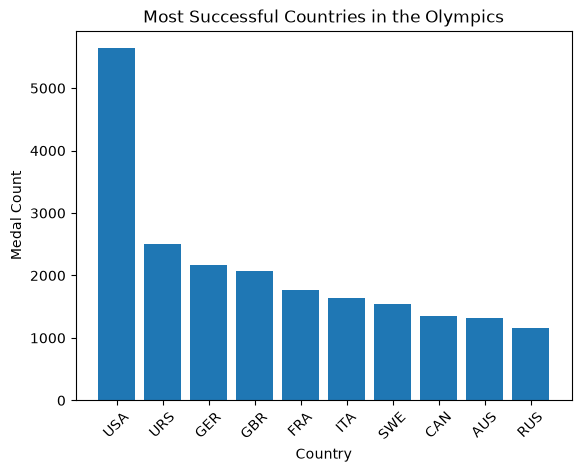

In [34]:

medal_counts= (
    df.dropna(subset=["Medal"])
      .groupby("NOC")["Medal"]
      .count()
      .sort_values(ascending=False)
)

print(medal_counts.head(10))
plt.bar(medal_counts.head(10).index, medal_counts.head(10).values)
plt.xlabel("Country")
plt.ylabel("Medal Count")
plt.title("Most Successful Countries in the Olympics")
plt.xticks(rotation=45)
plt.show()

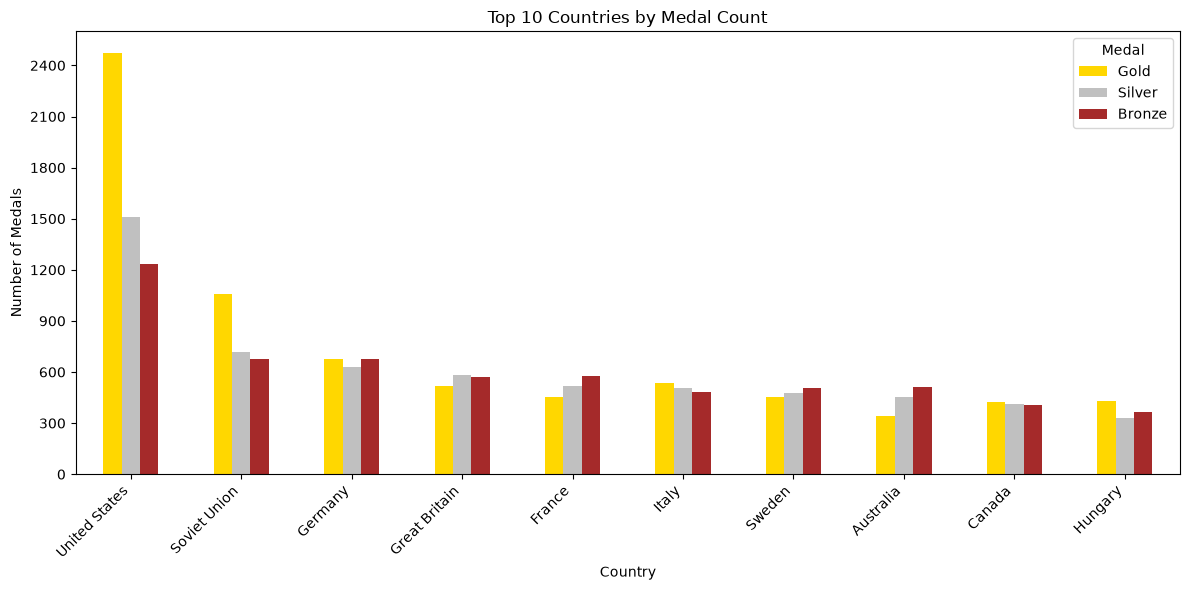

In [ ]:
# Get medal counts by country
medal_counts = (
    df.dropna(subset=["Medal"])
      .groupby(["Team", "Medal"])
      .size()
      .unstack(fill_value=0)
)

# Calculate total medals
medal_counts["Total"] = medal_counts.sum(axis=1)

# Get top 10 countries
top_10 = medal_counts.sort_values(
    "Total",
    ascending=False
).head(10)

# Remove Total because we only want the three medal types
top_10_medals = top_10[["Gold", "Silver", "Bronze"]]

# Plot clustered bar chart
top_10_medals.plot(
    kind="bar",
    figsize=(12,6),
     color=["gold", "silver", "brown"]
)

plt.xlabel("Country")
plt.ylabel("Number of Medals")
plt.title("Top 10 Countries by Medal Count")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Medal")
plt.ylim(0, 2600)
plt.yticks(range(0, 2601, 300))
plt.tight_layout()
plt.show()